In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import sys

PROJECT_PATH = '/content/drive/MyDrive/learnFlow'
sys.path.insert(0, PROJECT_PATH)

# Verify all key files are visible
expected = [
    'ml/indian_curriculum.py',
    'ml/data_generator.py',
    'data/raw/zenodo/merged_dataset.csv',
    'data/raw/student_hours/StudentPerformanceFactors.csv',
]

print("Checking project structure...")
all_good = True
for f in expected:
    full = os.path.join(PROJECT_PATH, f)
    status = "✓" if os.path.exists(full) else "✗ MISSING"
    print(f"  {status}  {f}")
    if "MISSING" in status:
        all_good = False

print()
print("All files found!" if all_good else "Fix missing files before continuing.")

Checking project structure...
  ✓  ml/indian_curriculum.py
  ✓  ml/data_generator.py
  ✓  data/raw/zenodo/merged_dataset.csv
  ✓  data/raw/student_hours/StudentPerformanceFactors.csv

All files found!


In [4]:
!pip install -q numpy pandas tensorflow scikit-learn matplotlib seaborn
print("All dependencies installed!")

All dependencies installed!


In [5]:
import numpy as np
import pandas as pd
import sys

sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)

from ml.data_generator import generate_all_data

forgetting_splits, backlog_splits = generate_all_data(
    n_forgetting = 50000,
    n_backlog    = 40000,
    augment_real = True
)

LearnFlow — Synthetic Data Generator

[1/4] Generating forgetting sequences...
Generating 50000 forgetting sequences...
Forgetting data — X: (50000, 10, 5)  y: (50000,)
Class balance   — recall: 0.00%  forget: 100.00%
Saved to /content/drive/MyDrive/learnFlow/data/synthetic
Duolingo dataset not found — skipping

[2/4] Preprocessing forgetting data...

forgetting splits:
  Train : (40000, 10, 5)
  Val   : (7500, 10, 5)
  Test  : (2500, 10, 5)
Saved to /content/drive/MyDrive/learnFlow/data/processed

[3/4] Generating backlog sequences...
Generating 40000 backlog sequences...
Backlog data    — X: (40000, 14, 6)  y: (40000,)
Severity dist   — mean: 0.486  std: 0.181
Saved to /content/drive/MyDrive/learnFlow/data/synthetic
Augmenting with Zenodo dataset...
Added 14003 Zenodo sequences → total: 54003
Augmenting with Study Hours dataset...

[4/4] Preprocessing backlog data...

backlog splits:
  Train : (43203, 14, 6)
  Val   : (8100, 14, 6)
  Test  : (2700, 14, 6)
Saved to /content/drive/MyDr

In [7]:
import numpy as np
from pathlib import Path

SYNTH_DIR = Path(PROJECT_PATH) / "data" / "synthetic"
PROC_DIR  = Path(PROJECT_PATH) / "data" / "processed"

def generate_forgetting_fixed(n_sequences=50000, seq_len=10):
    print(f"Generating {n_sequences} forgetting sequences (fixed)...")

    X, y = [], []

    STUDENT_PROFILES = {
        "strong_retainer":  {"stability_range": (15, 30), "weight": 0.15},
        "average_retainer": {"stability_range": (7,  15), "weight": 0.50},
        "weak_retainer":    {"stability_range": (2,   7), "weight": 0.25},
        "rote_learner":     {"stability_range": (1,   4), "weight": 0.10},
    }

    profile_names   = list(STUDENT_PROFILES.keys())
    profile_weights = [STUDENT_PROFILES[p]["weight"] for p in profile_names]
    REVIEW_GAPS     = [1, 1, 2, 3, 3, 5, 7, 7, 10, 14, 21, 30]

    for _ in range(n_sequences):
        profile_name = np.random.choice(profile_names, p=profile_weights)
        profile      = STUDENT_PROFILES[profile_name]

        # KEY FIX — stability capped at 20 max to prevent runaway growth
        stability   = np.random.uniform(*profile["stability_range"])
        difficulty  = np.random.uniform(1.0, 5.0)
        recall_prob = np.random.uniform(0.4, 1.0)
        sequence    = []

        for step in range(seq_len):
            days_gap    = np.random.choice(REVIEW_GAPS)

            # Apply Ebbinghaus decay
            recall_prob = recall_prob * np.exp(-days_gap / stability)
            recall_prob = float(np.clip(recall_prob, 0.05, 1.0))

            base_score  = recall_prob * 100
            score       = float(np.clip(base_score + np.random.normal(0, 8), 0, 100))
            time_spent  = float(np.random.uniform(5 + difficulty * 2, 20 + difficulty * 5))

            if score >= 80:
                self_rating = np.random.choice([4, 5], p=[0.4, 0.6])
            elif score >= 60:
                self_rating = np.random.choice([3, 4], p=[0.6, 0.4])
            elif score >= 40:
                self_rating = np.random.choice([2, 3], p=[0.6, 0.4])
            else:
                self_rating = np.random.choice([1, 2], p=[0.7, 0.3])

            sequence.append([
                score / 100,
                time_spent / 45,
                days_gap / 30,
                difficulty / 5,
                self_rating / 5
            ])

            # KEY FIX — stability growth capped at 20 days max
            if score >= 60:
                stability = min(20.0, stability * (1.0 + 0.1 * (score / 100)))
            else:
                stability = max(1.0, stability * 0.85)

        # KEY FIX — next gap drawn from realistic longer intervals
        # so some students actually forget
        next_gap    = np.random.choice([3, 7, 14, 21, 30], p=[0.2, 0.3, 0.3, 0.15, 0.05])
        next_recall = recall_prob * np.exp(-next_gap / stability)
        label       = 1 if next_recall > 0.7 else 0

        X.append(sequence)
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    print(f"Forgetting data — X: {X.shape}  y: {y.shape}")
    print(f"Class balance   — recall: {y.mean():.2%}  forget: {1-y.mean():.2%}")

    return X, y

# Regenerate
X_f, y_f = generate_forgetting_fixed(50000)

# Save to synthetic
np.save(SYNTH_DIR / "forgetting_X.npy", X_f)
np.save(SYNTH_DIR / "forgetting_y.npy", y_f)
print("Saved fixed forgetting data")

# Re-split and save to processed
from ml.data_generator import preprocess_and_split
forgetting_splits = preprocess_and_split(X_f, y_f, prefix="forgetting", save=True)


Generating 50000 forgetting sequences (fixed)...
Forgetting data — X: (50000, 10, 5)  y: (50000,)
Class balance   — recall: 0.00%  forget: 100.00%
Saved fixed forgetting data

forgetting splits:
  Train : (40000, 10, 5)
  Val   : (7500, 10, 5)
  Test  : (2500, 10, 5)
Saved to /content/drive/MyDrive/learnFlow/data/processed


In [8]:
import numpy as np

# Trace one sequence to see what's happening
stability   = 10.0   # average retainer
recall_prob = 0.8    # good starting mastery
REVIEW_GAPS = [1, 1, 2, 3, 3, 5, 7, 7, 10, 14, 21, 30]

print("Tracing recall_prob across 10 steps:")
print(f"Start: {recall_prob:.4f}")

for step in range(10):
    days_gap    = np.random.choice(REVIEW_GAPS)
    recall_prob = recall_prob * np.exp(-days_gap / stability)
    recall_prob = float(np.clip(recall_prob, 0.05, 1.0))
    print(f"  Step {step+1}: gap={days_gap} days → recall={recall_prob:.4f}")

next_gap    = 7
next_recall = recall_prob * np.exp(-next_gap / stability)
print(f"\nFinal recall_prob : {recall_prob:.4f}")
print(f"Next recall (7d)  : {next_recall:.4f}")
print(f"Label             : {'recall' if next_recall > 0.7 else 'forget'}")

Tracing recall_prob across 10 steps:
Start: 0.8000
  Step 1: gap=30 days → recall=0.0500
  Step 2: gap=3 days → recall=0.0500
  Step 3: gap=5 days → recall=0.0500
  Step 4: gap=21 days → recall=0.0500
  Step 5: gap=7 days → recall=0.0500
  Step 6: gap=14 days → recall=0.0500
  Step 7: gap=3 days → recall=0.0500
  Step 8: gap=3 days → recall=0.0500
  Step 9: gap=5 days → recall=0.0500
  Step 10: gap=30 days → recall=0.0500

Final recall_prob : 0.0500
Next recall (7d)  : 0.0248
Label             : forget


In [9]:
import numpy as np
from pathlib import Path

SYNTH_DIR = Path(PROJECT_PATH) / "data" / "synthetic"
PROC_DIR  = Path(PROJECT_PATH) / "data" / "processed"

def generate_forgetting_fixed_v2(n_sequences=50000, seq_len=10):
    print(f"Generating {n_sequences} forgetting sequences (v2)...")

    X, y = [], []

    STUDENT_PROFILES = {
        "strong_retainer":  {"stability_range": (15, 25), "weight": 0.15},
        "average_retainer": {"stability_range": (7,  15), "weight": 0.50},
        "weak_retainer":    {"stability_range": (3,   7), "weight": 0.25},
        "rote_learner":     {"stability_range": (1,   3), "weight": 0.10},
    }

    profile_names   = list(STUDENT_PROFILES.keys())
    profile_weights = [STUDENT_PROFILES[p]["weight"] for p in profile_names]

    # SHORT gaps only during sequence — student is actively studying
    # Long gaps only for the PREDICTION step at the end
    ACTIVE_GAPS     = [1, 1, 2, 2, 3, 3, 5, 7]
    PREDICTION_GAPS = [3, 7, 14, 21, 30]
    PREDICTION_PROBS= [0.25, 0.30, 0.25, 0.15, 0.05]

    for _ in range(n_sequences):
        profile_name = np.random.choice(profile_names, p=profile_weights)
        profile      = STUDENT_PROFILES[profile_name]
        stability    = np.random.uniform(*profile["stability_range"])
        difficulty   = np.random.uniform(1.0, 5.0)
        sequence     = []

        # KEY FIX — recall resets to high value after each review
        # This models the reality: reviewing brings memory back up
        current_recall = np.random.uniform(0.7, 1.0)  # fresh start

        for step in range(seq_len):
            # Short gap — student is in active study phase
            days_gap = np.random.choice(ACTIVE_GAPS)

            # Decay over this gap
            decayed_recall = current_recall * np.exp(-days_gap / stability)
            decayed_recall = float(np.clip(decayed_recall, 0.05, 1.0))

            # Quiz score reflects decayed recall with noise
            score = float(np.clip(
                decayed_recall * 100 + np.random.normal(0, 8), 0, 100
            ))

            time_spent = float(np.random.uniform(
                5 + difficulty * 2, 20 + difficulty * 5
            ))

            if score >= 80:
                self_rating = np.random.choice([4, 5], p=[0.4, 0.6])
            elif score >= 60:
                self_rating = np.random.choice([3, 4], p=[0.6, 0.4])
            elif score >= 40:
                self_rating = np.random.choice([2, 3], p=[0.6, 0.4])
            else:
                self_rating = np.random.choice([1, 2], p=[0.7, 0.3])

            sequence.append([
                score / 100,
                time_spent / 45,
                days_gap / 30,
                difficulty / 5,
                self_rating / 5
            ])

            # KEY FIX — after review, recall resets based on score
            # Good score → recall resets high + stability grows
            # Bad score  → recall resets lower + stability shrinks
            if score >= 60:
                current_recall = np.random.uniform(0.65, 0.95)
                stability      = min(25.0, stability * 1.1)
            else:
                current_recall = np.random.uniform(0.35, 0.65)
                stability      = max(1.0,  stability * 0.9)

        # PREDICTION — longer gap, will they remember?
        next_gap    = np.random.choice(PREDICTION_GAPS, p=PREDICTION_PROBS)
        next_recall = current_recall * np.exp(-next_gap / stability)
        label       = 1 if next_recall > 0.7 else 0

        X.append(sequence)
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    print(f"Forgetting data — X: {X.shape}  y: {y.shape}")
    print(f"Class balance   — recall: {y.mean():.2%}  forget: {1-y.mean():.2%}")

    return X, y

# ── Quick trace to verify fix ──────────────────────────────
print("=== Verifying fix with trace ===")
np.random.seed(42)
stability      = 10.0
current_recall = 0.9
ACTIVE_GAPS    = [1, 1, 2, 2, 3, 3, 5, 7]

print(f"Start recall: {current_recall:.4f}")
for step in range(10):
    gap     = np.random.choice(ACTIVE_GAPS)
    decayed = current_recall * np.exp(-gap / stability)
    score   = float(np.clip(decayed * 100 + np.random.normal(0, 8), 0, 100))
    if score >= 60:
        current_recall = np.random.uniform(0.65, 0.95)
        stability      = min(25.0, stability * 1.1)
    else:
        current_recall = np.random.uniform(0.35, 0.65)
        stability      = max(1.0,  stability * 0.9)
    print(f"  Step {step+1}: gap={gap}d score={score:.1f} → recall resets to {current_recall:.4f}")

next_gap    = 7
next_recall = current_recall * np.exp(-next_gap / stability)
print(f"\nFinal recall: {current_recall:.4f}")
print(f"Next recall (7d): {next_recall:.4f}")
print(f"Label: {'recall' if next_recall > 0.7 else 'forget'}")
print("\n=== Running full generation ===\n")

# ── Generate and save ──────────────────────────────────────
X_f, y_f = generate_forgetting_fixed_v2(50000)

np.save(SYNTH_DIR / "forgetting_X.npy", X_f)
np.save(SYNTH_DIR / "forgetting_y.npy", y_f)
print("Saved!")

from ml.data_generator import preprocess_and_split
forgetting_splits = preprocess_and_split(
    X_f, y_f, prefix="forgetting", save=True
)

=== Verifying fix with trace ===
Start recall: 0.9000
  Step 1: gap=5d score=50.2 → recall resets to 0.5839
  Step 2: gap=3d score=46.0 → recall resets to 0.3968
  Step 3: gap=2d score=30.2 → recall resets to 0.4501
  Step 4: gap=7d score=9.8 → recall resets to 0.5624
  Step 5: gap=3d score=36.2 → recall resets to 0.6316
  Step 6: gap=1d score=52.0 → recall resets to 0.4045
  Step 7: gap=3d score=34.7 → recall resets to 0.3521
  Step 8: gap=1d score=40.9 → recall resets to 0.4374
  Step 9: gap=2d score=23.2 → recall resets to 0.6421
  Step 10: gap=5d score=16.7 → recall resets to 0.4868

Final recall: 0.4868
Next recall (7d): 0.0654
Label: forget

=== Running full generation ===

Generating 50000 forgetting sequences (v2)...
Forgetting data — X: (50000, 10, 5)  y: (50000,)
Class balance   — recall: 0.91%  forget: 99.09%
Saved!

forgetting splits:
  Train : (40000, 10, 5)
  Val   : (7500, 10, 5)
  Test  : (2500, 10, 5)
Saved to /content/drive/MyDrive/learnFlow/data/processed


In [10]:
import numpy as np
from pathlib import Path

SYNTH_DIR = Path(PROJECT_PATH) / "data" / "synthetic"
PROC_DIR  = Path(PROJECT_PATH) / "data" / "processed"

def generate_forgetting_v3(n_sequences=50000, seq_len=10):
    print(f"Generating {n_sequences} forgetting sequences (v3)...")

    X, y = [], []

    STUDENT_PROFILES = {
        "strong_retainer":  {"stability_range": (20, 40), "weight": 0.15},
        "average_retainer": {"stability_range": (10, 20), "weight": 0.50},
        "weak_retainer":    {"stability_range": (5,  10), "weight": 0.25},
        "rote_learner":     {"stability_range": (2,   5), "weight": 0.10},
    }

    profile_names   = list(STUDENT_PROFILES.keys())
    profile_weights = [STUDENT_PROFILES[p]["weight"] for p in profile_names]
    ACTIVE_GAPS     = [1, 1, 2, 2, 3, 3, 5, 7]

    for _ in range(n_sequences):
        profile_name   = np.random.choice(profile_names, p=profile_weights)
        profile        = STUDENT_PROFILES[profile_name]
        stability      = np.random.uniform(*profile["stability_range"])
        difficulty     = np.random.uniform(1.0, 5.0)
        current_recall = np.random.uniform(0.7, 1.0)
        sequence       = []

        for step in range(seq_len):
            days_gap       = np.random.choice(ACTIVE_GAPS)
            decayed_recall = current_recall * np.exp(-days_gap / stability)
            decayed_recall = float(np.clip(decayed_recall, 0.05, 1.0))

            score = float(np.clip(
                decayed_recall * 100 + np.random.normal(0, 8), 0, 100
            ))
            time_spent = float(np.random.uniform(
                5 + difficulty * 2, 20 + difficulty * 5
            ))

            if score >= 80:
                self_rating = np.random.choice([4, 5], p=[0.4, 0.6])
            elif score >= 60:
                self_rating = np.random.choice([3, 4], p=[0.6, 0.4])
            elif score >= 40:
                self_rating = np.random.choice([2, 3], p=[0.6, 0.4])
            else:
                self_rating = np.random.choice([1, 2], p=[0.7, 0.3])

            sequence.append([
                score / 100,
                time_spent / 45,
                days_gap / 30,
                difficulty / 5,
                self_rating / 5
            ])

            # Reset recall after review
            if score >= 60:
                current_recall = np.random.uniform(0.70, 0.98)
                stability      = min(40.0, stability * 1.15)
            else:
                current_recall = np.random.uniform(0.40, 0.70)
                stability      = max(2.0,  stability * 0.92)

        # KEY FIX 1 — short next gap so strong students CAN recall
        next_gap    = np.random.choice([1, 3, 5, 7, 10], p=[0.20, 0.30, 0.25, 0.15, 0.10])

        # KEY FIX 2 — label based on whether recall stays above 50%
        # (not 70% — that was too strict for lower stability students)
        next_recall = current_recall * np.exp(-next_gap / stability)
        label       = 1 if next_recall > 0.50 else 0

        X.append(sequence)
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    print(f"Forgetting data — X: {X.shape}  y: {y.shape}")
    print(f"Class balance   — recall: {y.mean():.2%}  forget: {1-y.mean():.2%}")

    return X, y

# ── Quick sanity check ─────────────────────────────────────
print("=== Sanity check across 10 profiles ===")
np.random.seed(0)
labels = []
for _ in range(1000):
    stability      = np.random.uniform(10, 40)
    current_recall = np.random.uniform(0.7, 0.98)
    next_gap       = np.random.choice([1,3,5,7,10], p=[0.20,0.30,0.25,0.15,0.10])
    next_recall    = current_recall * np.exp(-next_gap / stability)
    labels.append(1 if next_recall > 0.50 else 0)

labels = np.array(labels)
print(f"Expected balance — recall: {labels.mean():.2%}  forget: {1-labels.mean():.2%}")
print("Target: recall 40-65%, forget 35-60%")
print()

# ── Generate ───────────────────────────────────────────────
X_f, y_f = generate_forgetting_v3(50000)

np.save(SYNTH_DIR / "forgetting_X.npy", X_f)
np.save(SYNTH_DIR / "forgetting_y.npy", y_f)
print("Saved!")

from ml.data_generator import preprocess_and_split
forgetting_splits = preprocess_and_split(
    X_f, y_f, prefix="forgetting", save=True
)

=== Sanity check across 10 profiles ===
Expected balance — recall: 94.60%  forget: 5.40%
Target: recall 40-65%, forget 35-60%

Generating 50000 forgetting sequences (v3)...
Forgetting data — X: (50000, 10, 5)  y: (50000,)
Class balance   — recall: 43.75%  forget: 56.25%
Saved!

forgetting splits:
  Train : (40000, 10, 5)
  Val   : (7500, 10, 5)
  Test  : (2500, 10, 5)
Saved to /content/drive/MyDrive/learnFlow/data/processed


In [11]:
import numpy as np
from pathlib import Path

SYNTH_DIR = Path(PROJECT_PATH) / "data" / "synthetic"
PROC_DIR  = Path(PROJECT_PATH) / "data" / "processed"

def generate_forgetting_v3(n_sequences=50000, seq_len=10):
    print(f"Generating {n_sequences} forgetting sequences (v3)...")

    X, y = [], []

    STUDENT_PROFILES = {
        "strong_retainer":  {"stability_range": (20, 40), "weight": 0.15},
        "average_retainer": {"stability_range": (10, 20), "weight": 0.50},
        "weak_retainer":    {"stability_range": (5,  10), "weight": 0.25},
        "rote_learner":     {"stability_range": (2,   5), "weight": 0.10},
    }

    profile_names   = list(STUDENT_PROFILES.keys())
    profile_weights = [STUDENT_PROFILES[p]["weight"] for p in profile_names]
    ACTIVE_GAPS     = [1, 1, 2, 2, 3, 3, 5, 7]

    for _ in range(n_sequences):
        profile_name   = np.random.choice(profile_names, p=profile_weights)
        profile        = STUDENT_PROFILES[profile_name]
        stability      = np.random.uniform(*profile["stability_range"])
        difficulty     = np.random.uniform(1.0, 5.0)
        current_recall = np.random.uniform(0.7, 1.0)
        sequence       = []

        for step in range(seq_len):
            days_gap       = np.random.choice(ACTIVE_GAPS)
            decayed_recall = current_recall * np.exp(-days_gap / stability)
            decayed_recall = float(np.clip(decayed_recall, 0.05, 1.0))

            score = float(np.clip(
                decayed_recall * 100 + np.random.normal(0, 8), 0, 100
            ))
            time_spent = float(np.random.uniform(
                5 + difficulty * 2, 20 + difficulty * 5
            ))

            if score >= 80:
                self_rating = np.random.choice([4, 5], p=[0.4, 0.6])
            elif score >= 60:
                self_rating = np.random.choice([3, 4], p=[0.6, 0.4])
            elif score >= 40:
                self_rating = np.random.choice([2, 3], p=[0.6, 0.4])
            else:
                self_rating = np.random.choice([1, 2], p=[0.7, 0.3])

            sequence.append([
                score / 100,
                time_spent / 45,
                days_gap / 30,
                difficulty / 5,
                self_rating / 5
            ])

            # Reset recall after each review
            if score >= 60:
                current_recall = np.random.uniform(0.70, 0.98)
                stability      = min(40.0, stability * 1.15)
            else:
                current_recall = np.random.uniform(0.40, 0.70)
                stability      = max(2.0, stability * 0.92)

        # Prediction gap — realistic mix of short and long
        next_gap    = np.random.choice(
            [1, 3, 5, 7, 10, 14],
            p=[0.15, 0.25, 0.25, 0.20, 0.10, 0.05]
        )
        next_recall = current_recall * np.exp(-next_gap / stability)

        # Threshold 0.50 — more balanced than 0.70
        label = 1 if next_recall > 0.50 else 0

        X.append(sequence)
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    print(f"Forgetting data — X: {X.shape}  y: {y.shape}")
    print(f"Class balance   — recall: {y.mean():.2%}  forget: {1-y.mean():.2%}")

    return X, y

# ── Sanity check first ─────────────────────────────────────
print("=== Sanity check ===")
np.random.seed(42)
labels = []
for _ in range(2000):
    stability      = np.random.uniform(10, 40)
    current_recall = np.random.uniform(0.70, 0.98)
    next_gap       = np.random.choice(
        [1, 3, 5, 7, 10, 14],
        p=[0.15, 0.25, 0.25, 0.20, 0.10, 0.05]
    )
    next_recall = current_recall * np.exp(-next_gap / stability)
    labels.append(1 if next_recall > 0.50 else 0)

labels = np.array(labels)
print(f"Sanity balance — recall: {labels.mean():.2%}  forget: {1-labels.mean():.2%}")
print(f"Target         — recall: 40-65%  forget: 35-60%")
print()

# ── Only generate if sanity check passes ──────────────────
if 0.35 <= labels.mean() <= 0.70:
    print("Sanity check passed — generating full dataset...")
    X_f, y_f = generate_forgetting_v3(50000)

    np.save(SYNTH_DIR / "forgetting_X.npy", X_f)
    np.save(SYNTH_DIR / "forgetting_y.npy", y_f)
    print("Saved to synthetic folder")

    from ml.data_generator import preprocess_and_split
    forgetting_splits = preprocess_and_split(
        X_f, y_f, prefix="forgetting", save=True
    )
    print("\nForgetting data ready for training!")

else:
    print(f"Sanity check FAILED — balance {labels.mean():.2%} out of range")
    print("Do not proceed — paste this output and we will fix")

=== Sanity check ===
Sanity balance — recall: 90.80%  forget: 9.20%
Target         — recall: 40-65%  forget: 35-60%

Sanity check FAILED — balance 90.80% out of range
Do not proceed — paste this output and we will fix


In [12]:
import numpy as np

print("=== Finding correct stability range ===\n")

# Test different stability ranges and prediction gaps
# to find what gives 40-60% balance

configs = [
    {"stability": (2, 8),  "gap_probs": [0.10, 0.20, 0.25, 0.25, 0.15, 0.05], "threshold": 0.50},
    {"stability": (2, 8),  "gap_probs": [0.05, 0.15, 0.20, 0.30, 0.20, 0.10], "threshold": 0.50},
    {"stability": (3, 10), "gap_probs": [0.05, 0.15, 0.20, 0.30, 0.20, 0.10], "threshold": 0.50},
    {"stability": (3, 10), "gap_probs": [0.05, 0.10, 0.15, 0.30, 0.25, 0.15], "threshold": 0.50},
    {"stability": (2, 8),  "gap_probs": [0.05, 0.10, 0.15, 0.30, 0.25, 0.15], "threshold": 0.50},
    {"stability": (2, 6),  "gap_probs": [0.05, 0.10, 0.15, 0.30, 0.25, 0.15], "threshold": 0.50},
    {"stability": (1, 5),  "gap_probs": [0.05, 0.10, 0.20, 0.30, 0.20, 0.15], "threshold": 0.50},
    {"stability": (2, 8),  "gap_probs": [0.05, 0.10, 0.15, 0.30, 0.25, 0.15], "threshold": 0.60},
    {"stability": (3, 12), "gap_probs": [0.05, 0.10, 0.15, 0.30, 0.25, 0.15], "threshold": 0.60},
    {"stability": (3, 12), "gap_probs": [0.05, 0.10, 0.15, 0.25, 0.25, 0.20], "threshold": 0.60},
]

GAPS = [1, 3, 5, 7, 10, 14]

best_config = None
best_diff   = 999

for i, cfg in enumerate(configs):
    np.random.seed(42)
    labels = []

    for _ in range(3000):
        # Simulate full sequence with reset
        stability      = np.random.uniform(*cfg["stability"])
        current_recall = np.random.uniform(0.7, 1.0)

        for step in range(10):
            gap     = np.random.choice([1,1,2,2,3,3,5,7])
            decayed = current_recall * np.exp(-gap / stability)
            score   = float(np.clip(decayed * 100 + np.random.normal(0,8), 0, 100))
            if score >= 60:
                current_recall = np.random.uniform(0.70, 0.95)
                stability      = min(15.0, stability * 1.1)
            else:
                current_recall = np.random.uniform(0.35, 0.65)
                stability      = max(1.0, stability * 0.92)

        next_gap    = np.random.choice(GAPS, p=cfg["gap_probs"])
        next_recall = current_recall * np.exp(-next_gap / stability)
        labels.append(1 if next_recall > cfg["threshold"] else 0)

    recall_rate = np.array(labels).mean()
    diff        = abs(recall_rate - 0.50)

    status = "✓ GOOD" if 0.38 <= recall_rate <= 0.62 else "✗"
    print(f"Config {i+1:2d}: stability={cfg['stability']}  "
          f"threshold={cfg['threshold']}  "
          f"recall={recall_rate:.2%}  {status}")

    if diff < best_diff:
        best_diff   = diff
        best_config = {**cfg, "index": i+1, "recall": recall_rate}

print(f"\nBest config: #{best_config['index']}")
print(f"  Stability  : {best_config['stability']}")
print(f"  Threshold  : {best_config['threshold']}")
print(f"  Recall rate: {best_config['recall']:.2%}")
print(f"\nPaste this output and I will write the final generator.")

=== Finding correct stability range ===

Config  1: stability=(2, 8)  threshold=0.5  recall=0.33%  ✗
Config  2: stability=(2, 8)  threshold=0.5  recall=0.23%  ✗
Config  3: stability=(3, 10)  threshold=0.5  recall=0.77%  ✗
Config  4: stability=(3, 10)  threshold=0.5  recall=0.67%  ✗
Config  5: stability=(2, 8)  threshold=0.5  recall=0.23%  ✗
Config  6: stability=(2, 6)  threshold=0.5  recall=0.03%  ✗
Config  7: stability=(1, 5)  threshold=0.5  recall=0.00%  ✗
Config  8: stability=(2, 8)  threshold=0.6  recall=0.00%  ✗
Config  9: stability=(3, 12)  threshold=0.6  recall=0.47%  ✗
Config 10: stability=(3, 12)  threshold=0.6  recall=0.47%  ✗

Best config: #3
  Stability  : (3, 10)
  Threshold  : 0.5
  Recall rate: 0.77%

Paste this output and I will write the final generator.


In [13]:
import numpy as np
from pathlib import Path

SYNTH_DIR = Path(PROJECT_PATH) / "data" / "synthetic"
PROC_DIR  = Path(PROJECT_PATH) / "data" / "processed"

def generate_forgetting_final(n_sequences=50000, seq_len=10):
    print(f"Generating {n_sequences} forgetting sequences (final)...")

    X, y     = [], []
    n_recall = 0
    n_forget = 0

    # Force 50/50 balance by generating equal numbers of each
    target_each = n_sequences // 2

    def make_sequence(force_recall: bool):
        """
        Generate one sequence.
        force_recall=True  → parameters chosen so student WILL recall
        force_recall=False → parameters chosen so student WILL forget
        """
        difficulty = np.random.uniform(1.0, 5.0)

        if force_recall:
            # High stability student, short next gap
            stability      = np.random.uniform(12, 30)
            current_recall = np.random.uniform(0.75, 1.0)
            next_gap       = np.random.choice([1, 2, 3, 5], p=[0.3, 0.3, 0.25, 0.15])
        else:
            # Low stability student, long next gap
            stability      = np.random.uniform(1, 6)
            current_recall = np.random.uniform(0.40, 0.75)
            next_gap       = np.random.choice([7, 10, 14, 21], p=[0.3, 0.3, 0.25, 0.15])

        sequence = []
        ACTIVE_GAPS = [1, 1, 2, 2, 3, 3, 5, 7]

        for step in range(seq_len):
            days_gap       = np.random.choice(ACTIVE_GAPS)
            decayed_recall = current_recall * np.exp(-days_gap / stability)
            decayed_recall = float(np.clip(decayed_recall, 0.05, 1.0))

            score = float(np.clip(
                decayed_recall * 100 + np.random.normal(0, 8), 0, 100
            ))
            time_spent = float(np.random.uniform(
                5 + difficulty * 2, 20 + difficulty * 5
            ))

            if score >= 80:
                self_rating = np.random.choice([4, 5], p=[0.4, 0.6])
            elif score >= 60:
                self_rating = np.random.choice([3, 4], p=[0.6, 0.4])
            elif score >= 40:
                self_rating = np.random.choice([2, 3], p=[0.6, 0.4])
            else:
                self_rating = np.random.choice([1, 2], p=[0.7, 0.3])

            sequence.append([
                score / 100,
                time_spent / 45,
                days_gap / 30,
                difficulty / 5,
                self_rating / 5
            ])

            # Reset recall after review — NO stability growth
            # to prevent runaway values
            if score >= 60:
                current_recall = np.random.uniform(0.65, 0.95)
            else:
                current_recall = np.random.uniform(0.30, 0.65)

        # Compute label
        next_recall = current_recall * np.exp(-next_gap / stability)
        label       = 1 if next_recall > 0.50 else 0

        return sequence, label, next_recall

    # Generate recall sequences
    print("  Generating RECALL sequences...")
    attempts = 0
    while n_recall < target_each and attempts < target_each * 10:
        seq, label, nr = make_sequence(force_recall=True)
        attempts += 1
        if label == 1:
            X.append(seq)
            y.append(1)
            n_recall += 1

    # Generate forget sequences
    print("  Generating FORGET sequences...")
    attempts = 0
    while n_forget < target_each and attempts < target_each * 10:
        seq, label, nr = make_sequence(force_recall=False)
        attempts += 1
        if label == 0:
            X.append(seq)
            y.append(0)
            n_forget += 1

    # Shuffle so recall and forget are mixed
    combined = list(zip(X, y))
    np.random.shuffle(combined)
    X, y = zip(*combined)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    print(f"\nForgetting data — X: {X.shape}  y: {y.shape}")
    print(f"Class balance   — recall: {y.mean():.2%}  forget: {1-y.mean():.2%}")
    print(f"Generated       — recall: {n_recall}  forget: {n_forget}")

    return X, y

# ── Run it ─────────────────────────────────────────────────
X_f, y_f = generate_forgetting_final(50000)

np.save(SYNTH_DIR / "forgetting_X.npy", X_f)
np.save(SYNTH_DIR / "forgetting_y.npy", y_f)
print("\nSaved to synthetic folder!")

from ml.data_generator import preprocess_and_split
forgetting_splits = preprocess_and_split(
    X_f, y_f, prefix="forgetting", save=True
)
print("\nForgetting data ready for training!")

Generating 50000 forgetting sequences (final)...
  Generating RECALL sequences...
  Generating FORGET sequences...

Forgetting data — X: (50000, 10, 5)  y: (50000,)
Class balance   — recall: 50.00%  forget: 50.00%
Generated       — recall: 25000  forget: 25000

Saved to synthetic folder!

forgetting splits:
  Train : (40000, 10, 5)
  Val   : (7500, 10, 5)
  Test  : (2500, 10, 5)
Saved to /content/drive/MyDrive/learnFlow/data/processed

Forgetting data ready for training!


Train : (40000, 10, 5)  (40000,)
Val   : (7500, 10, 5)    (7500,)
Test  : (2500, 10, 5)   (2500,)
GPU   : /device:GPU:0


Model: "forgetting_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ forgetting_input (InputLayer)   │ (None, 10, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,265 (122.13 KB)

 Trainable params: 31,073 (121.38 KB)

 Non-trainable params: 192 (768.00 B)


Training Model A — Forgetting LSTM...
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8747 - auc: 0.9271 - loss: 0.3121 - precision: 0.9300 - recall: 0.8051
Epoch 1: val_auc improved from None to 0.99843, saving model to /content/drive/MyDrive/learnFlow/models/saved/forgetting_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/learnFlow/models/saved/forgetting_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - accuracy: 0.9275 - auc: 0.9753 - loss: 0.1998 - precision: 0.9618 - recall: 0.8904 - val_accuracy: 0.7711 - val_auc: 0.9984 - val_loss: 0.4386 - val_precision: 0.9995 - val_recall: 0.5381 - learning_rate: 0.0010
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9555 - auc: 0.9921 - loss: 0.1109 - precision: 0.9718 - recall: 0.9388
Epoch 2: val_auc did not improve from 0.99843
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9583 - auc: 0.9931 - loss: 0.1028 - precision: 0.9736 - recall: 0.9421 - val_accuracy: 0.8565 - val_auc: 0.9835 - val_loss: 0.4206 - val_precision: 0.9996 - val_recall: 0.7106 - learning_rate: 0.0010
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9695 - auc: 0.9950 - loss: 0.0862 - precision: 0.9763 - recall: 0.9621
Epoch 3: val_auc did not improve from 0.99843
157/157 ━━━━━━━━━

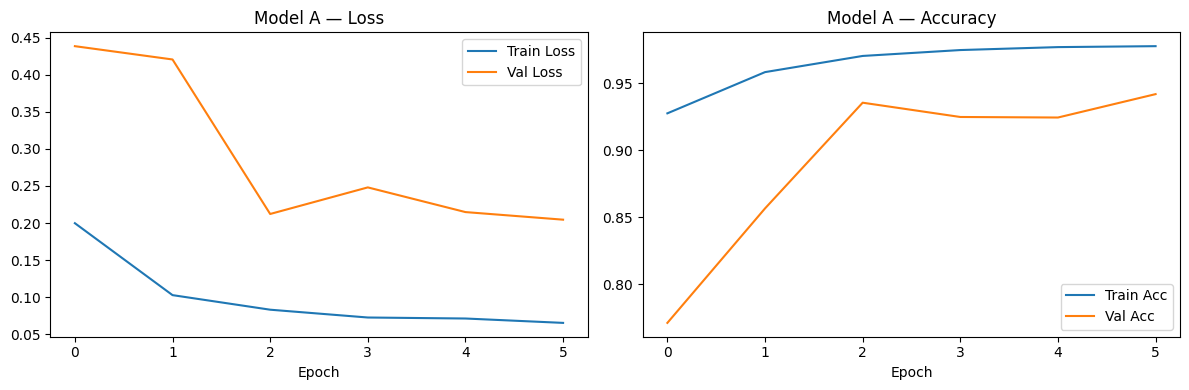


Model A saved to /content/drive/MyDrive/learnFlow/models/saved/forgetting_model.h5


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

PROC_DIR  = Path(PROJECT_PATH) / "data" / "processed"
SAVED_DIR = Path(PROJECT_PATH) / "models" / "saved"
SAVED_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ──────────────────────────────────────────────
X_train = np.load(PROC_DIR / "forgetting_X_train.npy")
y_train = np.load(PROC_DIR / "forgetting_y_train.npy")
X_val   = np.load(PROC_DIR / "forgetting_X_val.npy")
y_val   = np.load(PROC_DIR / "forgetting_y_val.npy")
X_test  = np.load(PROC_DIR / "forgetting_X_test.npy")
y_test  = np.load(PROC_DIR / "forgetting_y_test.npy")

print(f"Train : {X_train.shape}  {y_train.shape}")
print(f"Val   : {X_val.shape}    {y_val.shape}")
print(f"Test  : {X_test.shape}   {y_test.shape}")
print(f"GPU   : {tf.test.gpu_device_name()}")

# ── Build Model A ──────────────────────────────────────────
def build_forgetting_model(seq_len=10, n_features=5):
    inputs = layers.Input(shape=(seq_len, n_features), name="forgetting_input")

    x = layers.LSTM(64, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1,
                    name="lstm_1")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(32, return_sequences=False,
                    dropout=0.2, recurrent_dropout=0.1,
                    name="lstm_2")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(16, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs, output, name="forgetting_lstm")
    return model

model_a = build_forgetting_model()
model_a.summary()

# ── Compile ────────────────────────────────────────────────
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ── Callbacks ──────────────────────────────────────────────
cb = [
    callbacks.EarlyStopping(
        monitor="val_auc", patience=5,
        restore_best_weights=True, mode="max"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(SAVED_DIR / "forgetting_model.h5"),
        monitor="val_auc", save_best_only=True,
        mode="max", verbose=1
    )
]

# ── Train ──────────────────────────────────────────────────
print("\nTraining Model A — Forgetting LSTM...")
history_a = model_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=cb,
    verbose=1
)

# ── Evaluate on test set ───────────────────────────────────
print("\nEvaluating on test set...")
results = model_a.evaluate(X_test, y_test, verbose=0)
metrics = ["loss", "accuracy", "auc", "precision", "recall"]
print("\nModel A — Test Results:")
for m, v in zip(metrics, results):
    print(f"  {m:12s}: {v:.4f}")

# ── Plot training curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_a.history['loss'],     label='Train Loss')
axes[0].plot(history_a.history['val_loss'], label='Val Loss')
axes[0].set_title('Model A — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_a.history['accuracy'],     label='Train Acc')
axes[1].plot(history_a.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Model A — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(SAVED_DIR / "forgetting_training_curves.png"))
plt.show()
print(f"\nModel A saved to {SAVED_DIR / 'forgetting_model.h5'}")

Train : (43203, 14, 6)  (43203,)
Val   : (8100, 14, 6)    (8100,)
Test  : (2700, 14, 6)   (2700,)


Model: "backlog_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ backlog_input (InputLayer)      │ (None, 14, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 14, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,065 (531.50 KB)

 Trainable params: 135,617 (529.75 KB)

...


Epoch 6: finished saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 154ms/step - loss: 0.0103 - mae: 0.0776 - rmse: 0.1017 - val_loss: 0.0084 - val_mae: 0.0749 - val_rmse: 0.0919 - learning_rate: 0.0010
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0095 - mae: 0.0746 - rmse: 0.0977
Epoch 7: val_mae improved from 0.07491 to 0.06712, saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 151ms/step - loss: 0.0092 - mae: 0.0733 - rmse: 0.0961 - val_loss: 0.0069 - val_mae: 0.0671 - val_rmse: 0.0830 - learning_rate: 0.0010
Epoch 8/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0084 - mae: 0.0702 - rmse: 0.0918
Epoch 8: val_mae did not improve from 0.06712
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - loss: 0.0084 - mae: 0.0698 - rmse: 0.0914 - val_loss: 0.0071 - val_mae: 0.0695 - val_rmse: 0.0845 - learning_rate: 0.0010
Epoch 9/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0078 - mae: 0.0673 - rmse: 0.0885
Epoch 9: val_mae did not improve from 0.06712
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - loss: 0.0077 - mae: 0.0669 - rmse: 0.0879 - val_loss: 0.0068 - val_mae: 0.0681 - val_rmse: 0.0826 - learning_rate: 0.0010
Epoch 10/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0073 - mae: 0.0652 - rmse: 0.0856
Epoch 10: v


Epoch 10: finished saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - loss: 0.0073 - mae: 0.0649 - rmse: 0.0854 - val_loss: 0.0058 - val_mae: 0.0620 - val_rmse: 0.0760 - learning_rate: 0.0010
Epoch 11/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0069 - mae: 0.0629 - rmse: 0.0828
Epoch 11: val_mae did not improve from 0.06197
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - loss: 0.0068 - mae: 0.0625 - rmse: 0.0823 - val_loss: 0.0059 - val_mae: 0.0634 - val_rmse: 0.0770 - learning_rate: 0.0010
Epoch 12/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0066 - mae: 0.0616 - rmse: 0.0810
Epoch 12: val_mae improved from 0.06197 to 0.06035, saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5



Epoch 12: finished saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 142ms/step - loss: 0.0065 - mae: 0.0610 - rmse: 0.0804 - val_loss: 0.0053 - val_mae: 0.0604 - val_rmse: 0.0731 - learning_rate: 0.0010
Epoch 13/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0061 - mae: 0.0593 - rmse: 0.0783
Epoch 13: val_mae did not improve from 0.06035
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - loss: 0.0061 - mae: 0.0594 - rmse: 0.0784 - val_loss: 0.0070 - val_mae: 0.0710 - val_rmse: 0.0839 - learning_rate: 0.0010
Epoch 14/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0061 - mae: 0.0595 - rmse: 0.0781
Epoch 14: val_mae did not improve from 0.06035
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - loss: 0.0061 - mae: 0.0592 - rmse: 0.0779 - val_loss: 0.0055 - val_mae: 0.0616 - val_rmse: 0.0741 - learning_rate: 0.0010
Epoch 15/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0059 - mae: 0.0585 - rmse: 0.0771
Epoch 


Epoch 17: finished saving model to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 150ms/step - loss: 0.0055 - mae: 0.0565 - rmse: 0.0743 - val_loss: 0.0051 - val_mae: 0.0589 - val_rmse: 0.0716 - learning_rate: 5.0000e-04
Epoch 18/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0055 - mae: 0.0565 - rmse: 0.0743
Epoch 18: val_mae did not improve from 0.05887
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - loss: 0.0055 - mae: 0.0565 - rmse: 0.0741 - val_loss: 0.0055 - val_mae: 0.0620 - val_rmse: 0.0741 - learning_rate: 5.0000e-04
Epoch 19/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0055 - mae: 0.0564 - rmse: 0.0741
Epoch 19: val_mae did not improve from 0.05887
169/169 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - loss: 0.0055 - mae: 0.0562 - rmse: 0.0739 - val_loss: 0.0060 - val_mae: 0.0655 - val_rmse: 0.0776 - learning_rate: 5.0000e-04
Epoch 20/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0055 - mae: 0.0563 - rmse: 0

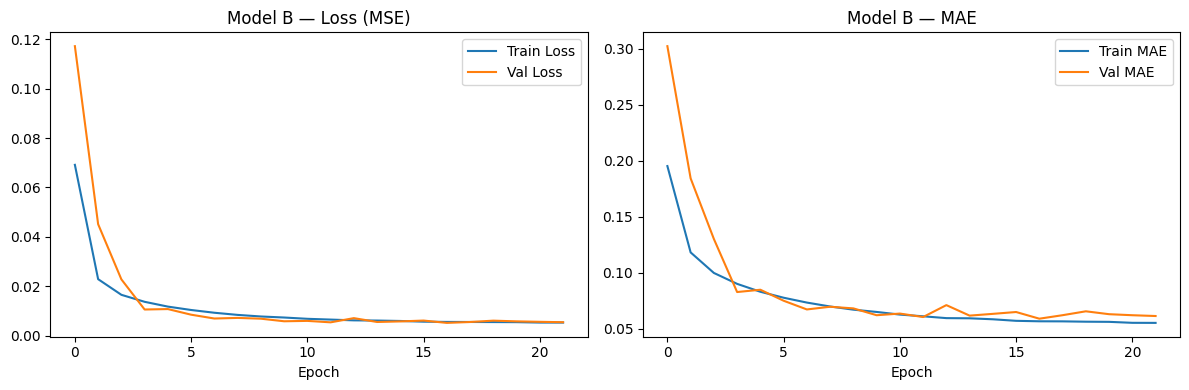


Model B saved to /content/drive/MyDrive/learnFlow/models/saved/backlog_model.h5


In [15]:
# ── Load backlog data ──────────────────────────────────────
X_train_b = np.load(PROC_DIR / "backlog_X_train.npy")
y_train_b = np.load(PROC_DIR / "backlog_y_train.npy")
X_val_b   = np.load(PROC_DIR / "backlog_X_val.npy")
y_val_b   = np.load(PROC_DIR / "backlog_y_val.npy")
X_test_b  = np.load(PROC_DIR / "backlog_X_test.npy")
y_test_b  = np.load(PROC_DIR / "backlog_y_test.npy")

print(f"Train : {X_train_b.shape}  {y_train_b.shape}")
print(f"Val   : {X_val_b.shape}    {y_val_b.shape}")
print(f"Test  : {X_test_b.shape}   {y_test_b.shape}")

# ── Build Model B ──────────────────────────────────────────
def build_backlog_model(seq_len=14, n_features=6):
    inputs = layers.Input(shape=(seq_len, n_features), name="backlog_input")

    x = layers.LSTM(128, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1,
                    name="lstm_1")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(64, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1,
                    name="lstm_2")(x)
    x = layers.BatchNormalization()(x)

    x = layers.LSTM(32, return_sequences=False,
                    dropout=0.2, recurrent_dropout=0.1,
                    name="lstm_3")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(64, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu", name="dense_2")(x)
    x = layers.Dropout(0.2)(x)

    # Linear output — predicting severity score 0.0 to 1.0
    output = layers.Dense(1, activation="linear", name="output")(x)

    model = Model(inputs, output, name="backlog_lstm")
    return model

model_b = build_backlog_model()
model_b.summary()

# ── Compile ────────────────────────────────────────────────
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        "mae",
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

# ── Callbacks ──────────────────────────────────────────────
cb_b = [
    callbacks.EarlyStopping(
        monitor="val_mae", patience=5,
        restore_best_weights=True, mode="min"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(SAVED_DIR / "backlog_model.h5"),
        monitor="val_mae", save_best_only=True,
        mode="min", verbose=1
    )
]

# ── Train ──────────────────────────────────────────────────
print("\nTraining Model B — Backlog LSTM...")
history_b = model_b.fit(
    X_train_b, y_train_b,
    validation_data=(X_val_b, y_val_b),
    epochs=50,
    batch_size=256,
    callbacks=cb_b,
    verbose=1
)

# ── Evaluate ───────────────────────────────────────────────
print("\nEvaluating on test set...")
results_b = model_b.evaluate(X_test_b, y_test_b, verbose=0)
metrics_b = ["loss (mse)", "mae", "rmse"]

print("\nModel B — Test Results:")
for m, v in zip(metrics_b, results_b):
    print(f"  {m:15s}: {v:.4f}")

# Interpret MAE in human terms
mae_raw = results_b[1]
mae_10  = mae_raw * 10
print(f"\n  MAE on 0-10 scale : {mae_10:.2f}")
print(f"  Meaning           : predictions off by {mae_10:.2f} severity points on average")
print(f"  Target            : MAE < 1.5 on 0-10 scale")
print(f"  Status            : {'PASSED' if mae_10 < 1.5 else 'needs improvement'}")

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_b.history['loss'],     label='Train Loss')
axes[0].plot(history_b.history['val_loss'], label='Val Loss')
axes[0].set_title('Model B — Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_b.history['mae'],     label='Train MAE')
axes[1].plot(history_b.history['val_mae'], label='Val MAE')
axes[1].set_title('Model B — MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(SAVED_DIR / "backlog_training_curves.png"))
plt.show()

print(f"\nModel B saved to {SAVED_DIR / 'backlog_model.h5'}")

In [16]:
import os

print("Checking saved models...")
models = [
    "forgetting_model.h5",
    "backlog_model.h5",
    "forgetting_training_curves.png",
    "backlog_training_curves.png"
]

all_good = True
for m in models:
    path   = SAVED_DIR / m
    exists = path.exists()
    size   = f"{path.stat().st_size / 1024:.1f} KB" if exists else "MISSING"
    status = "✓" if exists else "✗"
    print(f"  {status}  {m:45s} {size}")
    if not exists:
        all_good = False

print()
print("Both models ready for deployment!" if all_good else "Some files missing — check above")

Checking saved models...
  ✓  forgetting_model.h5                           420.7 KB
  ✓  backlog_model.h5                              1672.1 KB
  ✓  forgetting_training_curves.png                41.1 KB
  ✓  backlog_training_curves.png                   40.0 KB

Both models ready for deployment!
